# Regression

## Regresní modely v knihovně Scikit-learn

Scikit-learn poskytuje mnoho regresních algoritmů pro předpovídání spojitých hodnot. V tomto článku se zaměříme na 5 nejpoužívanějších regresních modelů, jejich vlastnosti, kód a praktické využití.

## 1. LinearRegression

### Popis

LinearRegression je nejjednodušší regresní model, který předpokládá lineární vztah mezi vstupními proměnnými a cílovou proměnnou. Model se snaží najít nejlepší přímku (nebo nadrovinu ve více dimenzích), která minimalizuje součet čtverců chyb mezi skutečnými a předpovězenými hodnotami.

### Kdy a kde použít

- Když existuje lineární závislost mezi proměnnými
- Pro jednoduché a interpretovatelné modely
- Jako výchozí (baseline) model
- Pro pochopení vlivu jednotlivých vlastností na cílovou proměnnou

### Výhody a nevýhody

**Výhody:**
- Jednoduchá implementace a rychlý výpočet
- Vysoká interpretovatelnost (koeficienty přímo určují vliv proměnných)
- Nízké riziko přetrénování pro jednoduché problémy
- Malý počet hyperparametrů

**Nevýhody:**
- Nedokáže modelovat nelineární vztahy
- Citlivý na odlehlé hodnoty
- Předpokládá nezávislost vlastností
- Může podtrénovat u komplexnějších dat

### Ukázka kódu

Střední kvadratická chyba: 0.5559
Koeficient determinace R²: 0.5758

Koeficienty modelu:
    Vlastnost  Koeficient
0      MedInc    0.448675
1    HouseAge    0.009724
2    AveRooms   -0.123323
3   AveBedrms    0.783145
4  Population   -0.000002
5    AveOccup   -0.003526
6    Latitude   -0.419792
7   Longitude   -0.433708


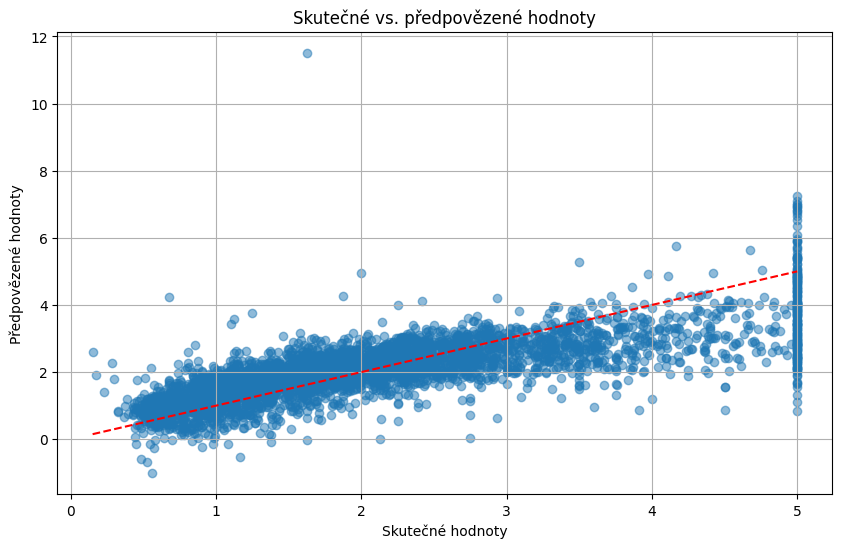

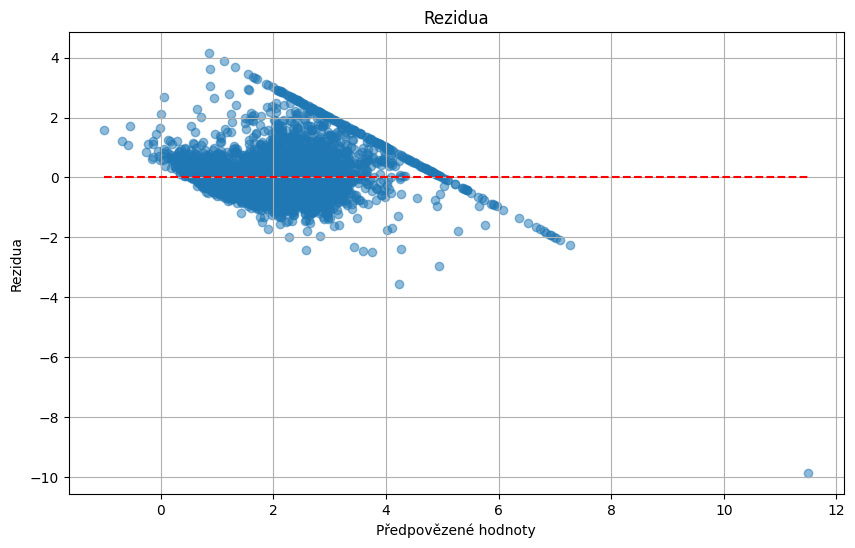

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Načtení datové sady
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Rozdělení dat na trénovací a testovací část
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vytvoření a trénování modelu
model = LinearRegression()
model.fit(X_train, y_train)

# Predikce
y_pred = model.predict(X_test)

# Vyhodnocení modelu
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Střední kvadratická chyba: {mse:.4f}")
print(f"Koeficient determinace R²: {r2:.4f}")

# Analýza koeficientů
coefficients = pd.DataFrame({
    'Vlastnost': housing.feature_names,
    'Koeficient': model.coef_
})
print("\nKoeficienty modelu:")
print(coefficients)

# Vizualizace skutečných vs. předpovězených hodnot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Skutečné hodnoty')
plt.ylabel('Předpovězené hodnoty')
plt.title('Skutečné vs. předpovězené hodnoty')
plt.grid(True)
plt.show()

# Vizualizace reziduí
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, y_test - y_pred, alpha=0.5)
plt.hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(), colors='r', linestyles='--')
plt.xlabel('Předpovězené hodnoty')
plt.ylabel('Rezidua')
plt.title('Rezidua')
plt.grid(True)
plt.show()

## 2. RandomForestRegressor

### Popis

RandomForestRegressor je ensemble metoda založená na rozhodovacích stromech. Vytváří několik rozhodovacích stromů na náhodných podmnožinách trénovacích dat a používá průměr jejich výstupů k finální předpovědi. Tento přístup pomáhá snižovat rozptyl a zlepšuje generalizaci.

### Kdy a kde použít

- Pro komplexní nelineární vztahy mezi daty
- Když existuje mnoho vlastností, včetně potenciálně irelevantních
- Pro úlohy vyžadující dobrou generalizaci bez nadměrného ladění
- Když potřebujete stanovit důležitost jednotlivých vlastností

### Výhody a nevýhody

**Výhody:**
- Zvládá nelineární závislosti bez nutnosti transformace dat
- Robustní vůči odlehlým hodnotám
- Automaticky vybírá důležité vlastnosti
- Nepotřebuje škálování vstupních dat

**Nevýhody:**
- Méně interpretovatelný než lineární modely
- Výpočetně náročnější
- Sklon k přetrénování při nevhodných hyperparametrech
- Vyžaduje více paměti a času při trénování na velkých datech

### Ukázka kódu

In [2]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.datasets import load_boston
# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd

# # Načtení datové sady (v novějších verzích scikit-learn použijte alternativní dataset)
# # V případě nedostupnosti lze použít: from sklearn.datasets import fetch_california_housing
# try:
#     boston = load_boston()
#     X, y = boston.data, boston.target
#     feature_names = boston.feature_names
# except:
#     from sklearn.datasets import fetch_california_housing
#     housing = fetch_california_housing()
#     X, y = housing.data, housing.target
#     feature_names = housing.feature_names

# # Rozdělení dat na trénovací a testovací část
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Vytvoření a trénování modelu
# rf = RandomForestRegressor(n_estimators=100, random_state=42)
# rf.fit(X_train, y_train)

# # Predikce
# y_pred = rf.predict(X_test)

# # Vyhodnocení modelu
# mse = mean_squared_error(y_test, y_pred)
# mae = mean_absolute_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)

# print(f"Střední kvadratická chyba: {mse:.4f}")
# print(f"Střední absolutní chyba: {mae:.4f}")
# print(f"Koeficient determinace R²: {r2:.4f}")

# # Ladění hyperparametrů
# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# grid_search = GridSearchCV(
#     RandomForestRegressor(random_state=42),
#     param_grid=param_grid,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1
# )
# grid_search.fit(X_train, y_train)

# print(f"\nNejlepší hyperparametry: {grid_search.best_params_}")

# # Použití nejlepšího modelu
# best_rf = grid_search.best_estimator_
# y_pred_best = best_rf.predict(X_test)

# mse_best = mean_squared_error(y_test, y_pred_best)
# r2_best = r2_score(y_test, y_pred_best)

# print(f"MSE nejlepšího modelu: {mse_best:.4f}")
# print(f"R² nejlepšího modelu: {r2_best:.4f}")

# # Důležitost vlastností
# feature_importances = pd.DataFrame({
#     'Vlastnost': feature_names,
#     'Důležitost': best_rf.feature_importances_
# })
# feature_importances = feature_importances.sort_values('Důležitost', ascending=False)

# plt.figure(figsize=(10, 6))
# plt.barh(feature_importances['Vlastnost'], feature_importances['Důležitost'])
# plt.xlabel('Důležitost')
# plt.title('Důležitost vlastností')
# plt.tight_layout()
# plt.show()

# # Vizualizace skutečných vs. předpovězených hodnot
# plt.figure(figsize=(10, 6))
# plt.scatter(y_test, y_pred_best, alpha=0.5)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
# plt.xlabel('Skutečné hodnoty')
# plt.ylabel('Předpovězené hodnoty')
# plt.title('Skutečné vs. předpovězené hodnoty')
# plt.grid(True)
# plt.show()

```
ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
    target = raw_df.values[1::2, 2]

Alternative datasets include the California housing dataset and the
Ames housing dataset. You can load the datasets as follows::

    from sklearn.datasets import fetch_california_housing
    housing = fetch_california_housing()

for the California housing dataset and::

    from sklearn.datasets import fetch_openml
    housing = fetch_openml(name="house_prices", as_frame=True)

for the Ames housing dataset.

[1] M Carlisle.
"Racist data destruction?"
<https://medium.com/@docintangible/racist-data-destruction-113e3eff54a8>

[2] Harrison Jr, David, and Daniel L. Rubinfeld.
"Hedonic housing prices and the demand for clean air."
Journal of environmental economics and management 5.1 (1978): 81-102.
<https://www.researchgate.net/publication/4974606_Hedonic_housing_prices_and_the_demand_for_clean_air>
```

Střední kvadratická chyba (MSE): 0.2554
Střední absolutní chyba (MAE): 0.3275
Koeficient determinace R²: 0.8051

Nejlepší hyperparametry: {'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
MSE nejlepšího modelu: 0.2539
R² nejlepšího modelu: 0.8063


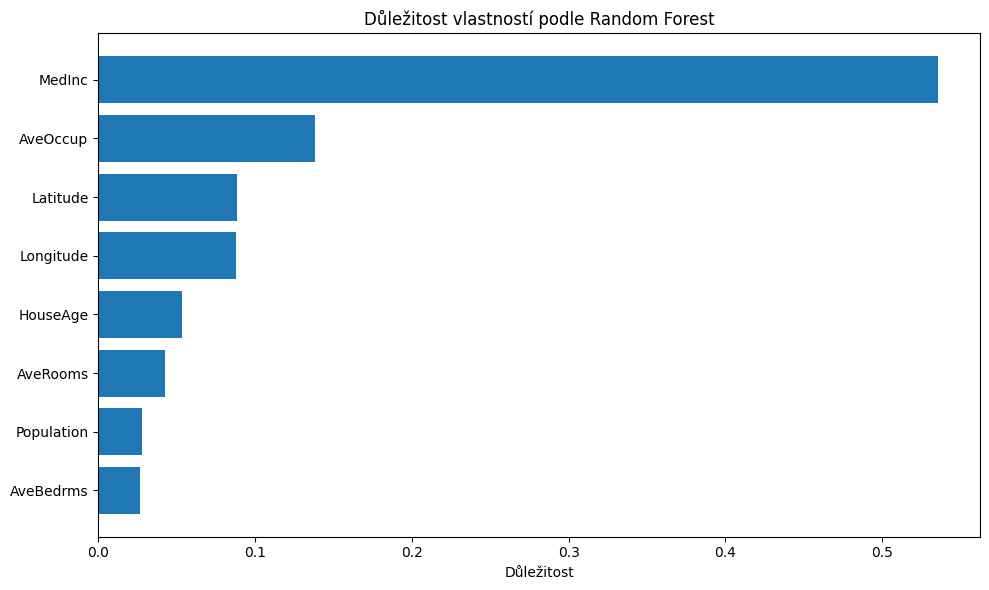

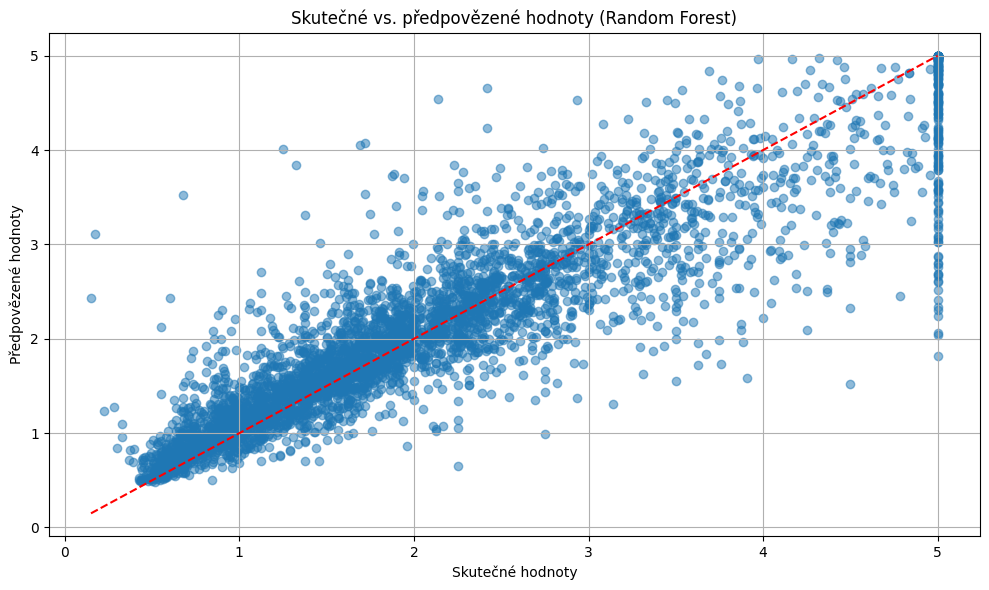

In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, methe.studio.2025.s01e08.1080p.web.h264-successfulcrab.mkvan_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Načtení datové sady California housing
housing = fetch_california_housing()
X, y = housing.data, housing.target
feature_names = housing.feature_names

# Rozdělení dat na trénovací a testovací část
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vytvoření a trénování modelu
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predikce
y_pred = rf.predict(X_test)

# Vyhodnocení modelu
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Střední kvadratická chyba (MSE): {mse:.4f}")
print(f"Střední absolutní chyba (MAE): {mae:.4f}")
print(f"Koeficient determinace R²: {r2:.4f}")

# Ladění hyperparametrů pomocí GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"\nNejlepší hyperparametry: {grid_search.best_params_}")

# Použití nejlepšího modelu
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

# Vyhodnocení nejlepšího modelu
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"MSE nejlepšího modelu: {mse_best:.4f}")
print(f"R² nejlepšího modelu: {r2_best:.4f}")

# Důležitost vlastností (feature importance)
feature_importances = pd.DataFrame({
    'Vlastnost': feature_names,
    'Důležitost': best_rf.feature_importances_
})
feature_importances = feature_importances.sort_values('Důležitost', ascending=False)

# Vizualizace důležitosti vlastností
plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Vlastnost'], feature_importances['Důležitost'])
plt.xlabel('Důležitost')
plt.title('Důležitost vlastností podle Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Vizualizace skutečných vs. předpovězených hodnot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Skutečné hodnoty')
plt.ylabel('Předpovězené hodnoty')
plt.title('Skutečné vs. předpovězené hodnoty (Random Forest)')
plt.grid(True)
plt.tight_layout()
plt.show()

### 🔧 Zrychlovací úpravy
1. ⚡ Zmenšený grid – méně kombinací v param_grid.
2. ⚡ Snížený počet cross-validací cv=3 místo 5.
3. ⚡ Menší počet stromů při ladění – ale stále dostatečně robustní.

Základní model bez ladění:
  MSE: 0.2554
  MAE: 0.3275
  R² : 0.8051

Nejlepší model po ladění:
  Nejlepší parametry: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
  MSE: 0.2559
  R² : 0.8047


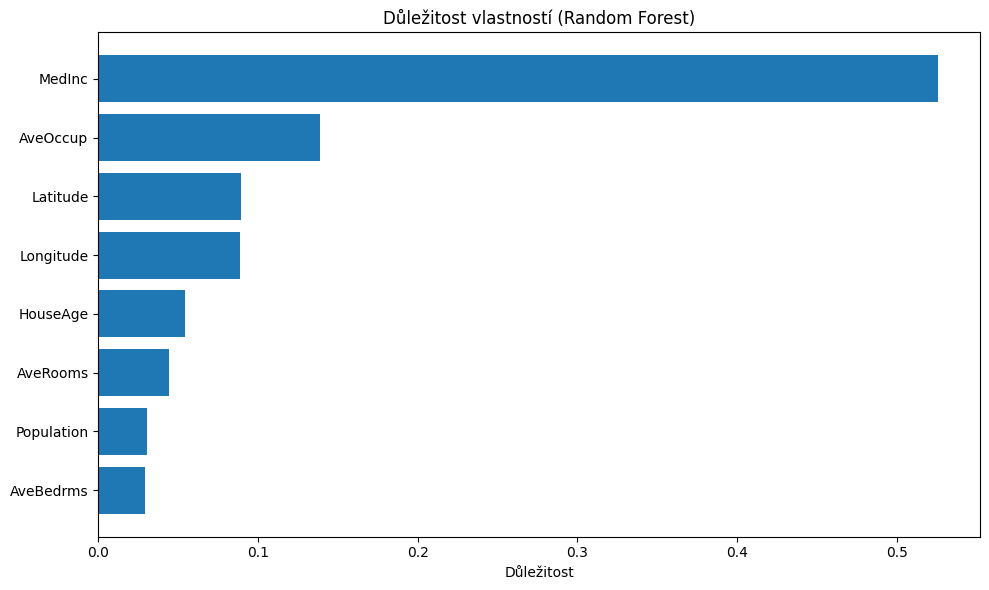

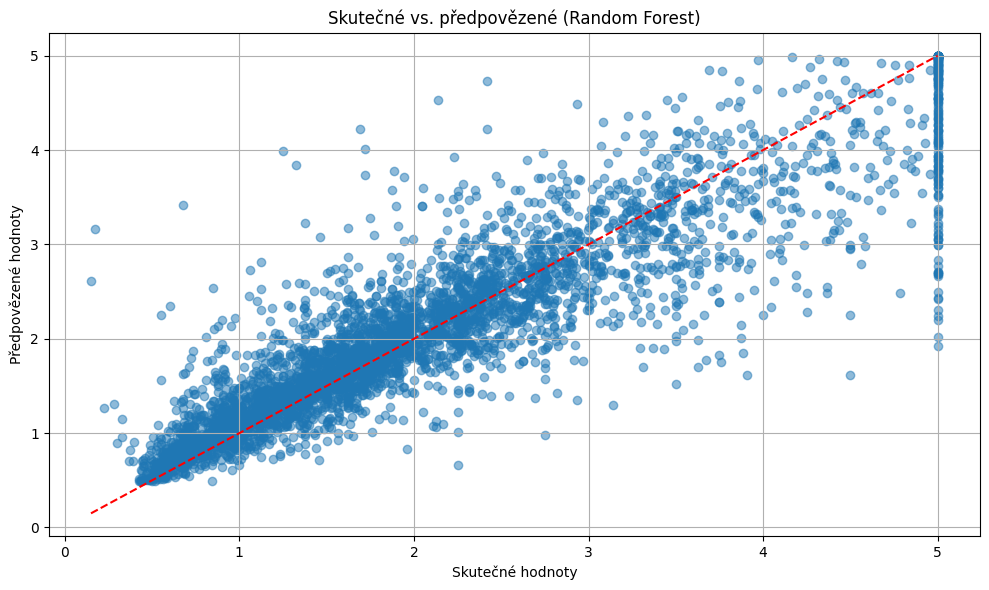

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Načtení datové sady California housing
housing = fetch_california_housing()
X, y = housing.data, housing.target
feature_names = housing.feature_names

# Rozdělení dat na trénovací a testovací část
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vytvoření a trénování základního modelu
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predikce
y_pred = rf.predict(X_test)

# Vyhodnocení modelu
print("Základní model bez ladění:")
print(f"  MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"  R² : {r2_score(y_test, y_pred):.4f}")

# ⚡ Zrychlené ladění hyperparametrů
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,                     # ⚡ zmenšeno z 5 na 3
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

# Nejlepší model po ladění
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

# Vyhodnocení nejlepšího modelu
print("\nNejlepší model po ladění:")
print(f"  Nejlepší parametry: {grid_search.best_params_}")
print(f"  MSE: {mean_squared_error(y_test, y_pred_best):.4f}")
print(f"  R² : {r2_score(y_test, y_pred_best):.4f}")

# ⚡ Důležitost vlastností
feature_importances = pd.DataFrame({
    'Vlastnost': feature_names,
    'Důležitost': best_rf.feature_importances_
}).sort_values('Důležitost', ascending=False)

# ⚡ Vizualizace důležitosti vlastností
plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Vlastnost'], feature_importances['Důležitost'])
plt.xlabel('Důležitost')
plt.title('Důležitost vlastností (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ⚡ Vizualizace predikce vs. realita
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Skutečné hodnoty')
plt.ylabel('Předpovězené hodnoty')
plt.title('Skutečné vs. předpovězené (Random Forest)')
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. SVR (Support Vector Regressor)

### Popis

SVR je implementace algoritmu Support Vector Machine pro regresi. Cílem je najít funkci, která se od všech trénovacích bodů odchyluje maximálně o hodnotu epsilon, přičemž je co nejvíce plochá. Používá tzv. "kernel trick" pro transformaci dat do vyšší dimenze, kde může být problém řešitelný lineárně.

### Kdy a kde použít

- Pro nelineární regresní problémy
- Pro datasety střední velikosti
- Když potřebujete vysokou přesnost a regularizaci
- Když jsou data zašuměná

### Výhody a nevýhody

**Výhody:**
- Efektivní ve vysokodimenzionálních prostorech
- Dobře funguje i s omezeným množstvím dat
- Versatilní díky různým typům kernelů
- Odolný vůči odlehlým hodnotám (s vhodným nastavením)

**Nevýhody:**
- Výpočetně náročný pro velké datasety
- Vyžaduje pečlivé ladění hyperparametrů
- Složitá interpretace modelu
- Citlivý na škálování vstupních dat

### Ukázka kódu

SVR s 'linear' kernelem:
  MSE: 15.7024
  R²: 0.9987
SVR s 'poly' kernelem:
  MSE: 2595.3953
  R²: 0.7811
SVR s 'rbf' kernelem:
  MSE: 245.6833
  R²: 0.9793

Nejlepší hyperparametry: {'C': np.float64(60.85448519014384), 'epsilon': np.float64(0.18052412368729154), 'gamma': np.float64(0.06605159298527952)}
MSE nejlepšího modelu: 111.3456
R² nejlepšího modelu: 0.9906


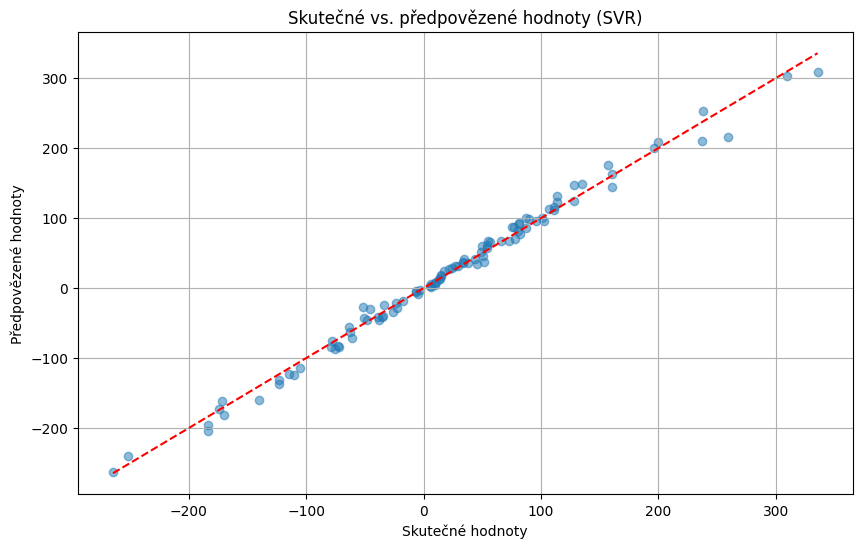

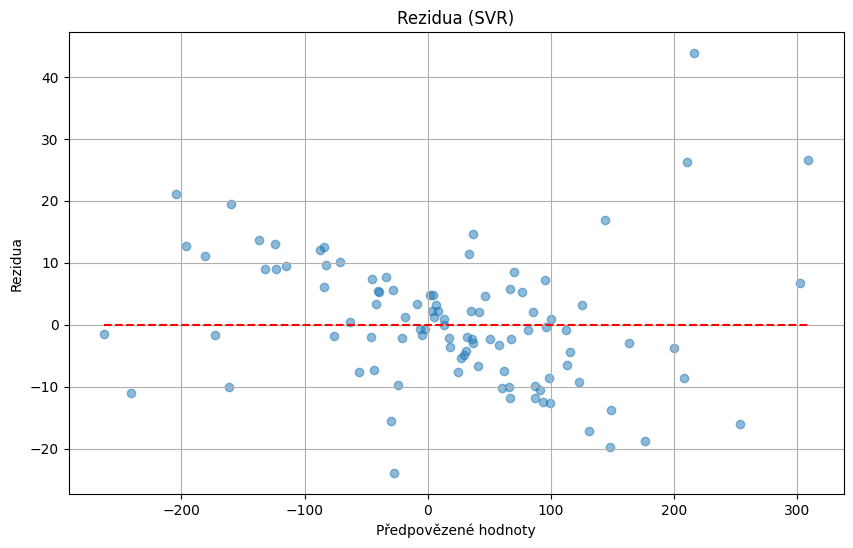

In [5]:
from sklearn.svm import SVR
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import uniform, randint

# Generování syntetických dat
X, y = make_regression(n_samples=500, n_features=5, noise=0.1, random_state=42)

# Rozdělení dat na trénovací a testovací část
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizace dat
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

# Vytvoření a trénování základních modelů s různými kernely
kernels = ['linear', 'poly', 'rbf']
svr_models = {}

for kernel in kernels:
    svr = SVR(kernel=kernel)
    svr.fit(X_train_scaled, y_train_scaled)
    svr_models[kernel] = svr

# Vyhodnocení modelů
for kernel, model in svr_models.items():
    y_pred_scaled = model.predict(X_test_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"SVR s '{kernel}' kernelem:")
    print(f"  MSE: {mse:.4f}")
    print(f"  R²: {r2:.4f}")

# Ladění hyperparametrů pro RBF kernel
param_distributions = {
    'C': uniform(0.1, 100),
    'gamma': uniform(0.001, 1),
    'epsilon': uniform(0.01, 1)
}

random_search = RandomizedSearchCV(
    SVR(kernel='rbf'),
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train_scaled)

print(f"\nNejlepší hyperparametry: {random_search.best_params_}")

# Použití nejlepšího modelu
best_svr = random_search.best_estimator_
y_pred_scaled_best = best_svr.predict(X_test_scaled)
y_pred_best = scaler_y.inverse_transform(y_pred_scaled_best.reshape(-1, 1)).ravel()

mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"MSE nejlepšího modelu: {mse_best:.4f}")
print(f"R² nejlepšího modelu: {r2_best:.4f}")

# Vizualizace skutečných vs. předpovězených hodnot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Skutečné hodnoty')
plt.ylabel('Předpovězené hodnoty')
plt.title('Skutečné vs. předpovězené hodnoty (SVR)')
plt.grid(True)
plt.show()

# Vizualizace reziduí
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_best, y_test - y_pred_best, alpha=0.5)
plt.hlines(y=0, xmin=y_pred_best.min(), xmax=y_pred_best.max(), colors='r', linestyles='--')
plt.xlabel('Předpovězené hodnoty')
plt.ylabel('Rezidua')
plt.title('Rezidua (SVR)')
plt.grid(True)
plt.show()

## 4. GradientBoostingRegressor

### Popis

GradientBoostingRegressor je pokročilá ensemble metoda, která buduje model postupně v sekvenci. Každý nový model se učí z chyb předchozích modelů, což vede k postupnému zlepšování prediktivní schopnosti. Typicky používá rozhodovací stromy jako základní modely.

### Kdy a kde použít

- Pro komplexní regresní úlohy
- Když požadujete vysokou přesnost predikce
- Pro strukturovaná tabulární data
- V soutěžích strojového učení (často patří mezi nejúspěšnější algoritmy)

### Výhody a nevýhody

**Výhody:**
- Vynikající prediktivní výkon
- Zvládá různé typy dat a vztahů
- Robustnost vůči odlehlým hodnotám
- Poskytuje důležitost vlastností

**Nevýhody:**
- Výpočetně náročný při trénování
- Riziko přetrénování při špatném nastavení
- Složitější ladění hyperparametrů
- Méně interpretovatelný než jednodušší modely

### Ukázka kódu

In [6]:
# from sklearn.ensemble import GradientBoostingRegressor
# from sklearn.datasets import fetch_california_housing
# from sklearn.model_selection import train_test_split, learning_curve
# from sklearn.metrics import mean_squared_error, r2_score
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd

# # Načtení datové sady
# housing = fetch_california_housing()
# X, y = housing.data, housing.target

# # Rozdělení dat na trénovací a testovací část
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Vytvoření a trénování modelu
# gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
# gb.fit(X_train, y_train)

# # Predikce
# y_pred = gb.predict(X_test)

# # Vyhodnocení modelu
# mse = mean_squared_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)

# print(f"Střední kvadratická chyba: {mse:.4f}")
# print(f"Koeficient determinace R²: {r2:.4f}")

# # Sledování chyby během trénování
# test_score = np.zeros((gb.n_estimators,), dtype=np.float64)
# for i, y_pred in enumerate(gb.staged_predict(X_test)):
#     test_score[i] = mean_squared_error(y_test, y_pred)

# train_score = np.zeros((gb.n_estimators,), dtype=np.float64)
# for i, y_pred in enumerate(gb.staged_predict(X_train)):
#     train_score[i] = mean_squared_error(y_train, y_pred)

# plt.figure(figsize=(10, 6))
# plt.plot(np.arange(gb.n_estimators) + 1, train_score, 'b-',
#          label='Trénovací MSE')
# plt.plot(np.arange(gb.n_estimators) + 1, test_score, 'r-',
#          label='Testovací MSE')
# plt.xlabel('Počet stromů')
# plt.ylabel('Střední kvadratická chyba')
# plt.title('Vývoj MSE během trénování')
# plt.legend()
# plt.grid(True)
# plt.show()

# # Důležitost vlastností
# feature_importances = pd.DataFrame({
#     'Vlastnost': housing.feature_names,
#     'Důležitost': gb.feature_importances_
# })
# feature_importances = feature_importances.sort_values('Důležitost', ascending=False)

# plt.figure(figsize=(10, 6))
# plt.barh(feature_importances['Vlastnost'], feature_importances['Důležitost'])
# plt.xlabel('Důležitost')
# plt.title('Důležitost vlastností')
# plt.tight_layout()
# plt.show()

# # Křivka učení
# train_sizes, train_scores, test_scores = learning_curve(
#     GradientBoostingRegressor(n_estimators=100, random_state=42),
#     X, y, train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='neg_mean_squared_error')

# train_scores_mean = -np.mean(train_scores, axis=1)
# train_scores_std = np.std(train_scores, axis=1)
# test_scores_mean = -np.mean(test_scores, axis=1)
# test_scores_std = np.std(test_scores, axis=1)

# plt.figure(figsize=(10, 6))
# plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
#                  train_scores_mean + train_scores_std, alpha=0.1, color="b")
# plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
#                  test_scores_mean + test_scores_std, alpha=0.1, color="r")
# plt.plot(train_sizes, train_scores_mean, 'o-', color="b", label="Trénovací MSE")
# plt.plot(train_sizes, test_scores_mean, 'o-', color="r", label="Validační MSE")
# plt.xlabel("Počet trénovacích vzorků")
# plt.ylabel("Střední kvadratická chyba")
# plt.title("Křivka učení pro GradientBoostingRegressor")
# plt.legend(loc="best")
# plt.grid(True)
# plt.show()

# # Vizualizace skutečných vs. předpovězených hodnot
# plt.figure(figsize=(10, 6))
# plt.scatter(y_test, y_pred, alpha=0.5)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
# plt.xlabel('Skutečné hodnoty')
# plt.ylabel('Předpovězené hodnoty')
# plt.title('Skutečné vs. předpovězené hodnoty')
# plt.grid(True)
# plt.show()

```
ValueError: x and y must be the same size
```

Střední kvadratická chyba: 0.3067
Koeficient determinace R²: 0.7659


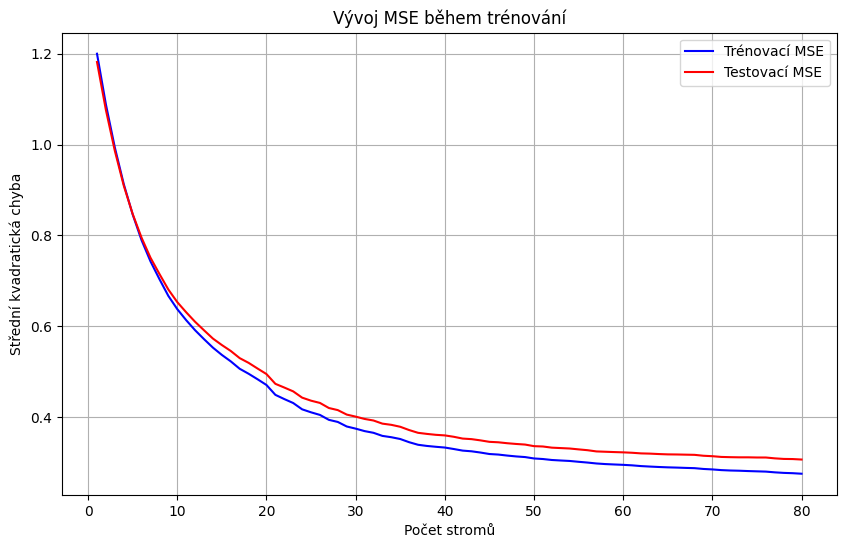

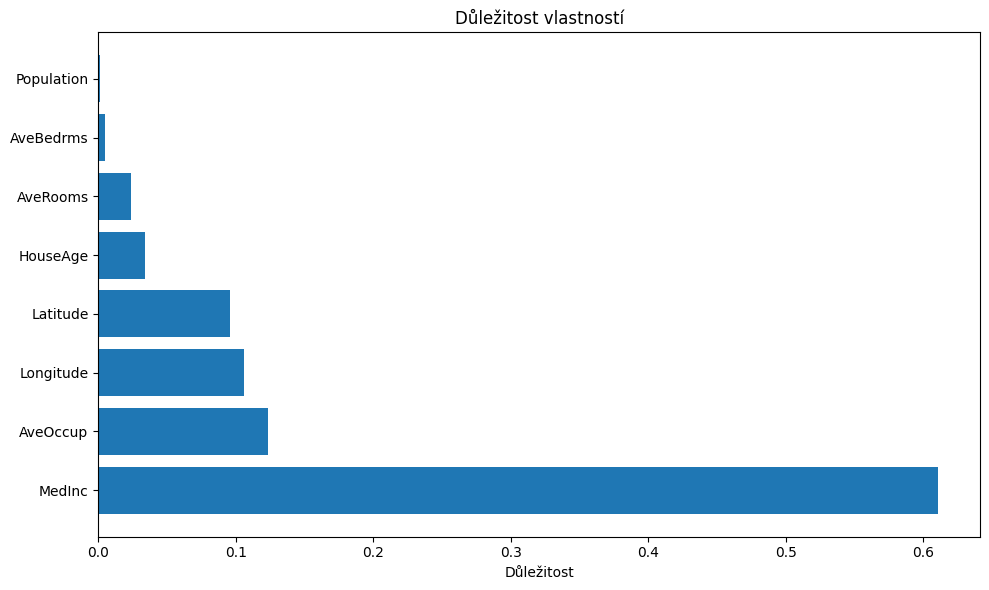

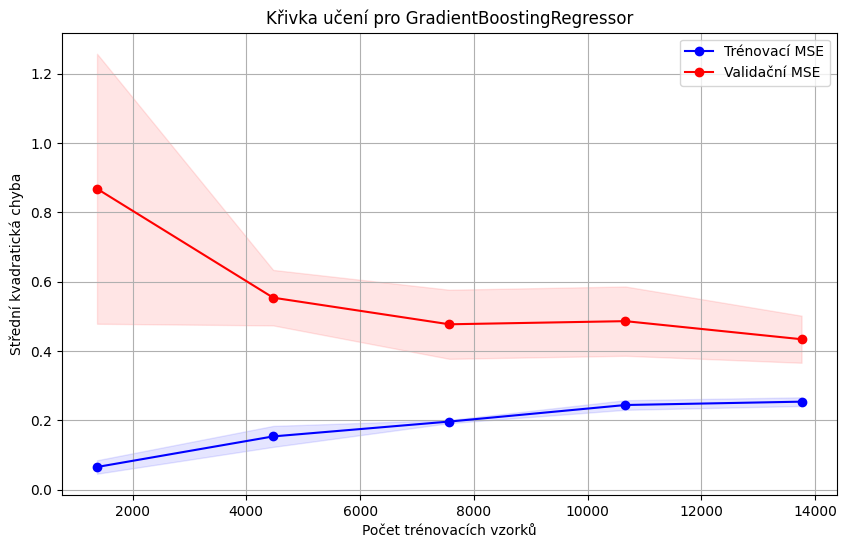

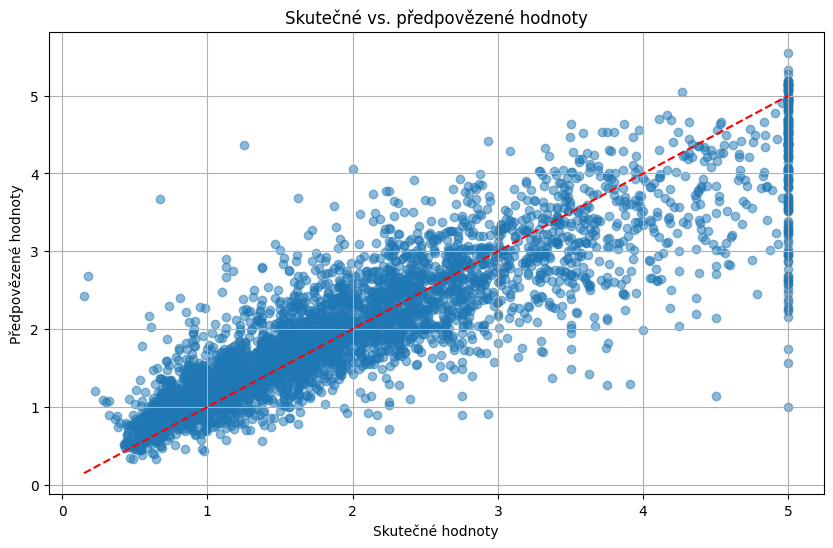

In [7]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Načtení datové sady
housing = fetch_california_housing()
X, y = housing.data, housing.target

# 2. Rozdělení dat
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model - rychlejší konfigurace
gb = GradientBoostingRegressor(
    n_estimators=80,       # méně stromů = rychlejší trénink
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)

# 4. Predikce
y_pred = gb.predict(X_test)

# 5. Vyhodnocení modelu
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Střední kvadratická chyba: {mse:.4f}")
print(f"Koeficient determinace R²: {r2:.4f}")

# 6. Vývoj chyby během trénování
test_score = np.zeros((gb.n_estimators,), dtype=np.float64)
for i, y_pred_stage_test in enumerate(gb.staged_predict(X_test)):
    test_score[i] = mean_squared_error(y_test, y_pred_stage_test)

train_score = np.zeros((gb.n_estimators,), dtype=np.float64)
for i, y_pred_stage_train in enumerate(gb.staged_predict(X_train)):
    train_score[i] = mean_squared_error(y_train, y_pred_stage_train)

plt.figure(figsize=(10, 6))
plt.plot(np.arange(gb.n_estimators) + 1, train_score, 'b-', label='Trénovací MSE')
plt.plot(np.arange(gb.n_estimators) + 1, test_score, 'r-', label='Testovací MSE')
plt.xlabel('Počet stromů')
plt.ylabel('Střední kvadratická chyba')
plt.title('Vývoj MSE během trénování')
plt.legend()
plt.grid(True)
plt.show()

# 7. Důležitost vlastností
feature_importances = pd.DataFrame({
    'Vlastnost': housing.feature_names,
    'Důležitost': gb.feature_importances_
}).sort_values('Důležitost', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Vlastnost'], feature_importances['Důležitost'])
plt.xlabel('Důležitost')
plt.title('Důležitost vlastností')
plt.tight_layout()
plt.show()

# 8. Křivka učení (rychlejší)
train_sizes, train_scores, test_scores = learning_curve(
    GradientBoostingRegressor(n_estimators=80, random_state=42),
    X, y,
    train_sizes=np.linspace(0.1, 1.0, 5),  # méně kroků
    cv=3,                                  # méně foldů
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

train_scores_mean = -np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="b")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="r")
plt.plot(train_sizes, train_scores_mean, 'o-', color="b", label="Trénovací MSE")
plt.plot(train_sizes, test_scores_mean, 'o-', color="r", label="Validační MSE")
plt.xlabel("Počet trénovacích vzorků")
plt.ylabel("Střední kvadratická chyba")
plt.title("Křivka učení pro GradientBoostingRegressor")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# 9. Skutečné vs. předpovězené hodnoty (opravené)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Skutečné hodnoty')
plt.ylabel('Předpovězené hodnoty')
plt.title('Skutečné vs. předpovězené hodnoty')
plt.grid(True)
plt.show()

## 5. ElasticNet

### Popis

ElasticNet je lineární regresní model s regularizací, která kombinuje penalty L1 a L2. Tento model je užitečný, když existuje mnoho korelovaných vlastností. Kombinuje vlastnosti Lasso (výběr vlastností) a Ridge regrese (zmenšování koeficientů), což pomáhá řešit multikolinearitu a předcházet přetrénování.

### Kdy a kde použít

- Pro data s mnoha korelovanými vlastnostmi
- Pro řídké modely (s mnoha nulovými koeficienty)
- Když chcete automatický výběr vlastností
- Pro finanční modelování, genomická data a další vysocedimenzionální problémy

### Výhody a nevýhody

**Výhody:**
- Kombinuje to nejlepší z Lasso a Ridge regrese
- Efektivní výběr vlastností
- Zvládá multikolinearitu
- Poskytuje interpretovatelnější modely než složitější algoritmy

**Nevýhody:**
- Stále omezen na lineární vztahy
- Vyžaduje pečlivé ladění dvou regularizačních parametrů (alpha a l1_ratio)
- Méně výkonný pro nelineární data
- Pro vysokou přesnost potřebuje správně škálovaná data

### Ukázka kódu

In [8]:
# from sklearn.linear_model import ElasticNet, Lasso, Ridge
# from sklearn.datasets import make_regression
# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import mean_squared_error, r2_score
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd

# # Generování syntetických dat s korelovanými vlastnostmi
# X, y = make_regression(n_samples=1000, n_features=50, n_informative=10, 
#                       noise=0.5, random_state=42)

# # Rozdělení dat na trénovací a testovací část
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Standardizace dat
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # Vytvoření a trénování různých modelů pro porovnání
# models = {
#     'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),
#     'Lasso': Lasso(alpha=0.1, random_state=42),
#     'Ridge': Ridge(alpha=0.1, random_state=42)
# }

# results = {}
# for name, model in models.items():
#     model.fit(X_train_scaled, y_train)
#     y_pred = model.predict(X_test_scaled)
#     results[name] = {
#         'mse': mean_squared_error(y_test, y_pred),
#         'r2': r2_score(y_test, y_pred),
#         'model': model
#     }
#     print(f"{name}:")
#     print(f"  MSE: {results[name]['mse']:.4f}")
#     print(f"  R²: {results[name]['r2']:.4f}")
#     print(f"  Počet nulových koeficientů: {np.sum(model.coef_ == 0)}/{len(model.coef_)}")

# # Ladění hyperparametrů pro ElasticNet
# param_grid = {
#     'alpha': [0.001, 0.01, 0.1, 1, 10, 100],
#     'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
# }

# grid_search = GridSearchCV(
#     ElasticNet(random_state=42, max_iter=10000),
#     param_grid=param_grid,
#     cv=5,
#     scoring='neg_mean_squared_error'
# )
# grid_search.fit(X_train_scaled, y_train)

# print(f"\nNejlepší hyperparametry: {grid_search.best_params_}")

# # Použití nejlepšího modelu
# best_elastic = grid_search.best_estimator_
# y_pred_best = best_elastic.predict(X_test_scaled)

# mse_best = mean_squared_error(y_test, y_pred_best)
# r2_best = r2_score(y_test, y_pred_best)

# print(f"MSE nejlepšího modelu: {mse_best:.4f}")
# print(f"R² nejlepšího modelu: {r2_best:.4f}")
# print(f"Počet nulových koeficientů: {np.sum(best_elastic.coef_ == 0)}/{len(best_elastic.coef_)}")

# # Vizualizace koeficientů různých modelů
# non_zero_coef = np.where(np.abs(results['ElasticNet']['model'].coef_) > 1e-10)[0]
# selected_features = non_zero_coef[:10]  # Zobrazíme jen prvních 10 nenulových vlastností

# coefs = pd.DataFrame()
# for name, result in results.items():
#     coefs[name] = result['model'].coef_
# coefs['Vlastnost'] = [f"X{i}" for i in range(X.shape[1])]

# plt.figure(figsize=(12, 8))
# for i, feature in enumerate(selected_features):
#     plt.subplot(2, 5, i + 1)
#     for name in models.keys():
#         plt.bar(name, coefs.loc[feature, name])
#     plt.title(f"Vlastnost {feature}")
#     plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# # Vizualizace cesty regularizace
# from sklearn.linear_model import enet_path

# alphas, coefs, _ = enet_path(X_train_scaled, y_train, l1_ratio=0.5, 
#                             fit_intercept=False, return_models=False)

# plt.figure(figsize=(12, 6))
# plt.plot(-np.log10(alphas), coefs.T)
# plt.xlabel('-log(alpha)')
# plt.ylabel('Koeficienty')
# plt.title('Cesta regularizace pro ElasticNet (l1_ratio=0.5)')
# plt.tight_layout()
# plt.show()

# # Vizualizace skutečných vs. předpovězených hodnot
# plt.figure(figsize=(10, 6))
# plt.scatter(y_test, y_pred_best, alpha=0.5)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
# plt.xlabel('Skutečné hodnoty')
# plt.ylabel('Předpovězené hodnoty')
# plt.title('Skutečné vs. předpovězené hodnoty (ElasticNet)')
# plt.grid(True)
# plt.show()

```
ValueError: ('Unexpected parameters in params', dict_keys(['fit_intercept', 'return_models']))
```

ElasticNet:
  MSE: 66.7013
  R²: 0.9974
  Počet nulových koeficientů: 7/50
Lasso:
  MSE: 0.3251
  R²: 1.0000
  Počet nulových koeficientů: 40/50
Ridge:
  MSE: 0.2496
  R²: 1.0000
  Počet nulových koeficientů: 0/50

Nejlepší hyperparametry: {'alpha': 0.001, 'l1_ratio': 0.9}
MSE nejlepšího modelu: 0.2485
R² nejlepšího modelu: 1.0000
Počet nulových koeficientů: 0/50


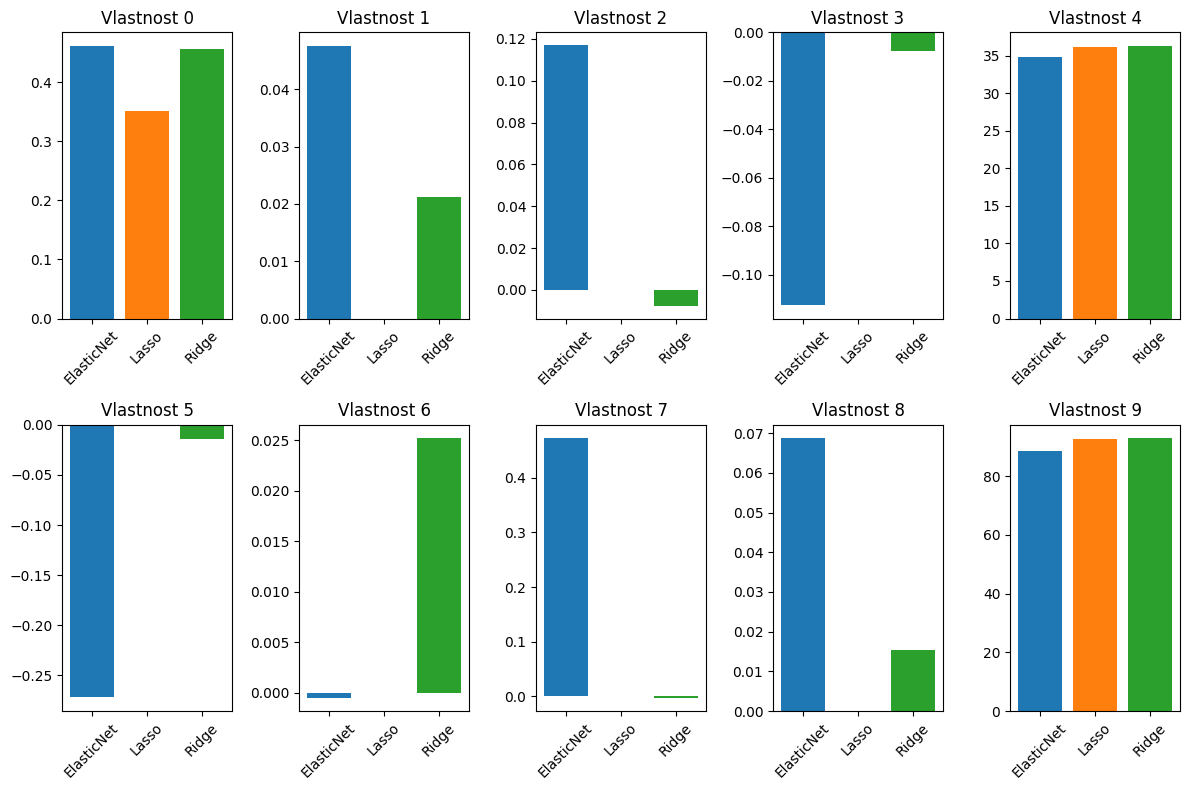

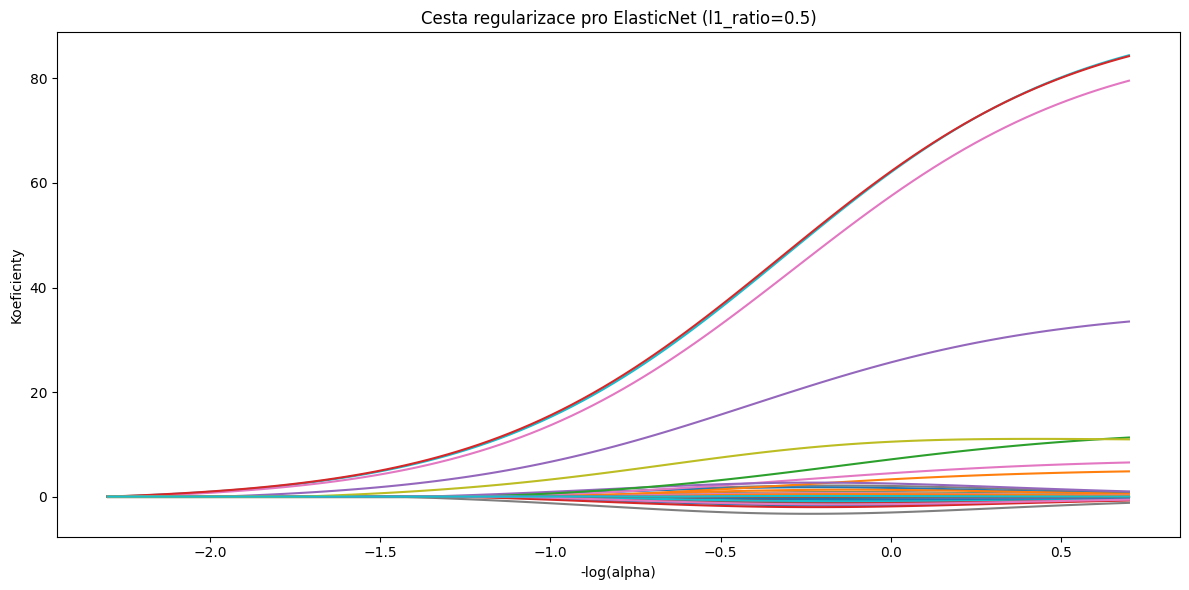

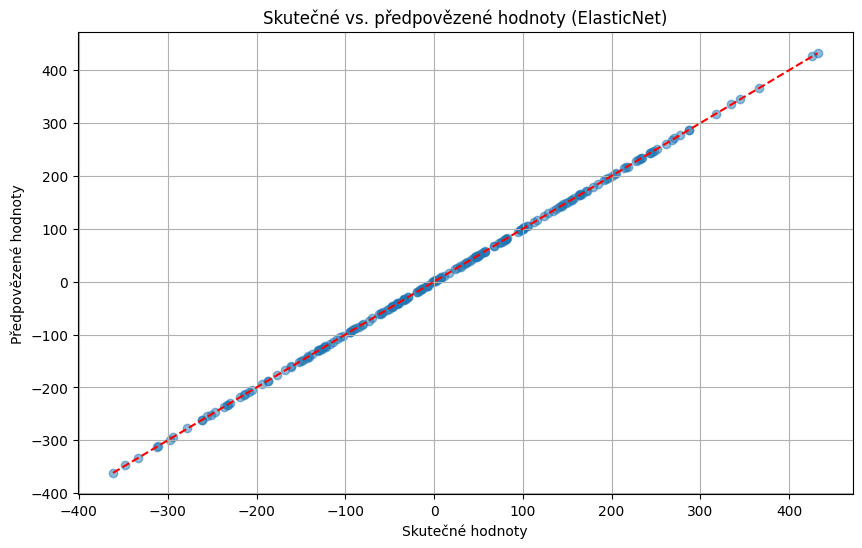

In [9]:
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Generování syntetických dat s korelovanými vlastnostmi
X, y = make_regression(n_samples=1000, n_features=50, n_informative=10, 
                      noise=0.5, random_state=42)

# Rozdělení dat na trénovací a testovací část
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizace dat
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Vytvoření a trénování různých modelů pro porovnání
models = {
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),
    'Lasso': Lasso(alpha=0.1, random_state=42),
    'Ridge': Ridge(alpha=0.1, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = {
        'mse': mean_squared_error(y_test, y_pred),
        'r2': r2_score(y_test, y_pred),
        'model': model
    }
    print(f"{name}:")
    print(f"  MSE: {results[name]['mse']:.4f}")
    print(f"  R²: {results[name]['r2']:.4f}")
    print(f"  Počet nulových koeficientů: {np.sum(model.coef_ == 0)}/{len(model.coef_)}")

# Ladění hyperparametrů pro ElasticNet
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

grid_search = GridSearchCV(
    ElasticNet(random_state=42, max_iter=10000),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)
grid_search.fit(X_train_scaled, y_train)

print(f"\nNejlepší hyperparametry: {grid_search.best_params_}")

# Použití nejlepšího modelu
best_elastic = grid_search.best_estimator_
y_pred_best = best_elastic.predict(X_test_scaled)

mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"MSE nejlepšího modelu: {mse_best:.4f}")
print(f"R² nejlepšího modelu: {r2_best:.4f}")
print(f"Počet nulových koeficientů: {np.sum(best_elastic.coef_ == 0)}/{len(best_elastic.coef_)}")

# Vizualizace koeficientů různých modelů
non_zero_coef = np.where(np.abs(results['ElasticNet']['model'].coef_) > 1e-10)[0]
selected_features = non_zero_coef[:10]  # Zobrazíme jen prvních 10 nenulových vlastností

coefs = pd.DataFrame()
for name, result in results.items():
    coefs[name] = result['model'].coef_
coefs['Vlastnost'] = [f"X{i}" for i in range(X.shape[1])]

plt.figure(figsize=(12, 8))
for i, feature in enumerate(selected_features):
    plt.subplot(2, 5, i + 1)
    for name in models.keys():
        plt.bar(name, coefs.loc[feature, name])
    plt.title(f"Vlastnost {feature}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Vizualizace cesty regularizace bez fit_intercept a return_models
from sklearn.linear_model import enet_path

alphas, coefs, _ = enet_path(X_train_scaled, y_train, l1_ratio=0.5)

plt.figure(figsize=(12, 6))
plt.plot(-np.log10(alphas), coefs.T)
plt.xlabel('-log(alpha)')
plt.ylabel('Koeficienty')
plt.title('Cesta regularizace pro ElasticNet (l1_ratio=0.5)')
plt.tight_layout()
plt.show()

# Vizualizace skutečných vs. předpovězených hodnot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Skutečné hodnoty')
plt.ylabel('Předpovězené hodnoty')
plt.title('Skutečné vs. předpovězené hodnoty (ElasticNet)')
plt.grid(True)
plt.show()

## Srovnávací tabulka regresních modelů

| Model | Rychlost trénování | Rychlost predikce | Interpretovatelnost | Nelineární vztahy | Odlehlé hodnoty | Vysokodim. data | Hyperparametry | Hlavní výhody | Hlavní nevýhody |
|-------|-------------------|-------------------|---------------------|-------------------|----------------|-----------------|--------------------|--------------|----------------|
| LinearRegression | Velmi rychlé | Velmi rychlé | Vysoká | Ne | Citlivý | Průměrné | Minimum | Jednoduchost, interpretace | Pouze lineární vztahy |
| RandomForestRegressor | Střední | Rychlé | Střední | Ano | Robustní | Dobré | Více | Vysoká přesnost, robustnost | Výpočetní náročnost, černá skříňka |
| SVR | Pomalé | Střední | Nízká | Ano | Robustní | Průměrné | Více | Přesnost pro komplexní data | Výpočetní náročnost, nutnost škálování |
| GradientBoostingRegressor | Pomalé | Střední | Nízká | Ano | Středně robustní | Dobré | Mnoho | Vysoká přesnost, versatilita | Složité ladění, černá skříňka |
| ElasticNet | Rychlé | Velmi rychlé | Vysoká | Ne | Středně citlivý | Velmi dobré | Několik | Výběr vlastností, regularizace | Omezen na lineární vztahy |